# 📘 Lecture 13: Statistics for Machine Learning, Maximum Likelihood Estimation (MLE), & KL Divergence Equivalence
**Course**: Probabilistic Machine Learning by Aayush  
**Video Reference**: [Lecture 13 - YouTube](https://youtu.be/MwTeQVVYtOc?si=7scaKkyrxJvucWGj)

---
### 📌 Executive Overview & Core Objectives
In this lecture, we begin our module on **Statistics for Machine Learning** and explore how model parameters $\boldsymbol{\theta}$ are learned from finite data via Model Fitting:
1. **Statistical Inference vs. Deep Learning Prediction**: Distinguishing statistical uncertainty quantification from deep learning point prediction.
2. **Maximum Likelihood Estimation (MLE)**: I.I.D. assumption, Likelihood $\mathcal{L}(\boldsymbol{\theta}) = \prod P(y_n \mid \boldsymbol{\theta})$, and Negative Log-Likelihood (NLL) objective minimization.
3. **Theoretical Justifications for MLE**:
   - MAP point approximation under uniform prior $P(\boldsymbol{\theta}) \propto 1$.
   - Mathematical equivalence between minimizing NLL and minimizing KL divergence $D_{\text{KL}}(\hat{P}_{data} \parallel P_{\boldsymbol{\theta}})$ to the empirical distribution $\hat{P}_{data}(y) = \frac{1}{N} \sum \delta(y - y_n)$.
4. **Complete Analytical Derivations & Code Verifications**:
   - **Bernoulli MLE**: Proving $\hat{\theta}_{MLE} = \frac{N_1}{N}$ (Empirical head fraction).
   - **Categorical MLE**: Lagrange Multiplier optimization $\mathcal{L}(\boldsymbol{\theta}, \lambda) = -\sum N_k \log \theta_k + \lambda(\sum \theta_k - 1) \implies \hat{\theta}_{k, MLE} = \frac{N_k}{N}$.
   - **Gaussian MLE**: Deriving sample mean $\hat{\mu}_{MLE} = \bar{y}$ and sample variance $\hat{\sigma}^2_{MLE} = \frac{1}{N} \sum (y_n - \bar{y})^2$ (and quantifying sample variance bias).

---


## 0️⃣ Environment Setup & Imports
We start by importing scientific computation, optimization, and plotting libraries.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for 100% reproducible results
np.random.seed(42)
print("✅ Libraries imported successfully! NumPy Version:", np.__version__)


✅ Libraries imported successfully! NumPy Version: 2.0.2


## 1️⃣ Model Fitting, Statistical Inference & MLE Formalism

### 1.1 Model Fitting Principle
Given a dataset $\mathcal{D} = \{y_1, y_2, \dots, y_N\}$ drawn i.i.d. from an underlying distribution, Model Fitting is the process of estimating unknown parameters $\boldsymbol{\theta}$.

### 1.2 Maximum Likelihood Estimation (MLE)
Under the i.i.d. assumption, the joint likelihood factors into the product of marginals:
$$P(\mathcal{D} \mid \boldsymbol{\theta}) = \prod_{n=1}^N P(y_n \mid x_n, \boldsymbol{\theta})$$

To avoid numerical underflow, we minimize the Negative Log-Likelihood (NLL):
$$\hat{\boldsymbol{\theta}}_{MLE} = \arg\min_{\boldsymbol{\theta}} \text{NLL}(\boldsymbol{\theta}) = \arg\min_{\boldsymbol{\theta}} \left( -\sum_{n=1}^N \log P(y_n \mid x_n, \boldsymbol{\theta}) \right)$$

- **Endogenous Variables ($Y$)**: Generated target variables whose density we model.
- **Exogenous Variables ($X$)**: Conditioning inputs.

## 2️⃣ Theoretical Justifications for MLE

### 2.1 Justification 1: MAP Point Approximation under Uniform Prior
The Maximum A Posteriori (MAP) estimate is:
$$\hat{\boldsymbol{\theta}}_{MAP} = \arg\max_{\boldsymbol{\theta}} \left[ \log P(\mathcal{D} \mid \boldsymbol{\theta}) + \log P(\boldsymbol{\theta}) \right]$$
If we assume an uninformative uniform prior $P(\boldsymbol{\theta}) \propto 1 \implies \log P(\boldsymbol{\theta}) = \text{const}$, MAP reduces exactly to MLE:
$$\hat{\boldsymbol{\theta}}_{MAP} = \hat{\boldsymbol{\theta}}_{MLE}$$

### 2.2 Justification 2: Minimizing KL Divergence to Empirical Distribution
Represent the training dataset $\mathcal{D}$ as an empirical distribution via Dirac spikes:
$$\hat{P}_{data}(y) = \frac{1}{N} \sum_{n=1}^N \delta(y - y_n)$$

The KL divergence between $\hat{P}_{data}$ and model distribution $P(y \mid \boldsymbol{\theta})$ is:
$$D_{\text{KL}}(\hat{P}_{data} \parallel P_{\boldsymbol{\theta}}) = \int \hat{P}_{data}(y) \log \frac{\hat{P}_{data}(y)}{P(y \mid \boldsymbol{\theta})} dy = \underbrace{-H(\hat{P}_{data})}_{\text{Constant w.r.t. } \boldsymbol{\theta}} - \int \hat{P}_{data}(y) \log P(y \mid \boldsymbol{\theta}) dy$$

Using the sifting property of Dirac impulses $\int \delta(y - y_n) \log P(y \mid \boldsymbol{\theta}) dy = \log P(y_n \mid \boldsymbol{\theta})$:
$$D_{\text{KL}}(\hat{P}_{data} \parallel P_{\boldsymbol{\theta}}) = \text{const} - \frac{1}{N} \sum_{n=1}^N \log P(y_n \mid \boldsymbol{\boldsymbol{\theta}}) = \text{const} + \frac{1}{N} \text{NLL}(\boldsymbol{\theta})$$

Minimizing KL divergence to the empirical data distribution is **mathematically identical** to minimizing NLL!

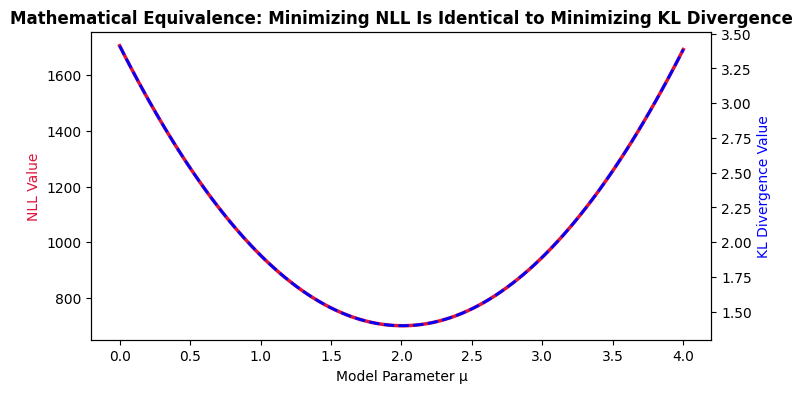

In [2]:
# Code Demonstration: Numerical Proof of Equivalence between NLL and KL Divergence
np.random.seed(42)
y_true_samples = np.random.normal(loc=2.0, scale=1.0, size=500)

grid_mu = np.linspace(0.0, 4.0, 100)
nll_vals = []
kl_vals = []

for mu_cand in grid_mu:
    # NLL under Gaussian model N(mu_cand, 1.0)
    nll = -np.sum(stats.norm.logpdf(y_true_samples, loc=mu_cand, scale=1.0))
    nll_vals.append(nll)

    # KL Divergence approximation
    # const - (1/N) * sum(log p(y_n | mu))
    kl_approx = (1.0 / len(y_true_samples)) * nll
    kl_vals.append(kl_approx)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(grid_mu, nll_vals, color='crimson', linewidth=2.5, label='Negative Log-Likelihood NLL(μ)')
ax1.set_xlabel('Model Parameter μ')
ax1.set_ylabel('NLL Value', color='crimson')

ax2 = ax1.twinx()
ax2.plot(grid_mu, kl_vals, color='blue', linestyle='--', linewidth=2, label='KL Divergence D_KL(P_data || P_μ)')
ax2.set_ylabel('KL Divergence Value', color='blue')

plt.title('Mathematical Equivalence: Minimizing NLL Is Identical to Minimizing KL Divergence', fontweight='bold')
plt.show()


## 3️⃣ Bernoulli MLE Derivation

### 3.1 Analytical Proof
For $N$ coin tosses $y_n \in \{0, 1\}$ with success probability $\theta = P(y = 1)$:
$$P(y_n \mid \theta) = \theta^{y_n} (1 - \theta)^{1 - y_n}$$

The NLL objective is:
$$\text{NLL}(\theta) = - \sum_{n=1}^N \left[ y_n \log \theta + (1 - y_n) \log(1 - \theta) \right] = - N_1 \log \theta - N_0 \log(1 - \theta)$$
where $N_1 = \sum y_n$ (count of heads) and $N_0 = N - N_1$ (count of tails) are the **Sufficient Statistics**.

Setting derivative to zero:
$$\frac{d \text{NLL}}{d\theta} = - \frac{N_1}{\theta} + \frac{N_0}{1 - \theta} = 0 \implies N_1(1 - \theta) = N_0 \theta \implies N_1 = \theta(N_1 + N_0)$$

$$\hat{\theta}_{MLE} = \frac{N_1}{N_1 + N_0} = \frac{N_1}{N} \quad (\text{Empirical Fraction of Successes})$$

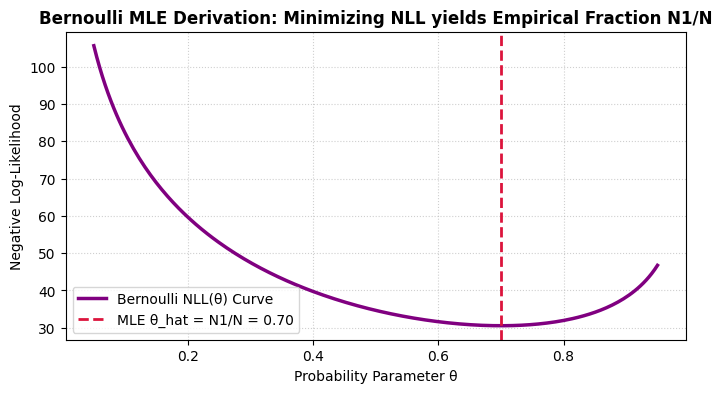

In [3]:
# Simulation & Visualization of Bernoulli NLL Convexity
N_tosses = 50
heads_count = 35 # N1 = 35, N0 = 15
y_coin = np.array([1]*heads_count + [0]*(N_tosses - heads_count))

grid_theta = np.linspace(0.05, 0.95, 200)
nll_bern = [- (heads_count * np.log(th) + (N_tosses - heads_count) * np.log(1 - th)) for th in grid_theta]

mle_theta_bern = heads_count / N_tosses # 35/50 = 0.70

plt.figure(figsize=(8, 4))
plt.plot(grid_theta, nll_bern, color='purple', linewidth=2.5, label='Bernoulli NLL(θ) Curve')
plt.axvline(mle_theta_bern, color='crimson', linestyle='--', linewidth=2, label=f'MLE θ_hat = N1/N = {mle_theta_bern:.2f}')
plt.xlabel('Probability Parameter θ')
plt.ylabel('Negative Log-Likelihood')
plt.title('Bernoulli MLE Derivation: Minimizing NLL yields Empirical Fraction N1/N', fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 4️⃣ Categorical MLE Derivation

### 4.1 Constrained Optimization via Lagrange Multipliers
For $K$-sided die outcomes $y_n \in \{1, 2, \dots, K\}$ with probability vector $\boldsymbol{\theta} = [\theta_1, \dots, \theta_K]^\top$ satisfying $\sum_{k=1}^K \theta_k = 1$:
$$\text{NLL}(\boldsymbol{\theta}) = - \sum_{k=1}^K N_k \log \theta_k$$
where $N_k = \sum_{n=1}^N \mathbb{I}(y_n = k)$ is the frequency count of category $k$.

Forming the Lagrangian:
$$\mathcal{L}(\boldsymbol{\theta}, \lambda) = - \sum_{k=1}^K N_k \log \theta_k + \lambda \left( \sum_{k=1}^K \theta_k - 1 \right)$$

Setting partial derivatives to zero:
1. $\frac{\partial \mathcal{L}}{\partial \theta_k} = - \frac{N_k}{\theta_k} + \lambda = 0 \implies N_k = \lambda \theta_k$
2. Summing over all $k=1 \dots K$:
   $$\sum_{k=1}^K N_k = \lambda \sum_{k=1}^K \theta_k \implies N = \lambda \cdot 1 \implies \lambda = N$$
3. Substituting $\lambda = N$ back:
   $$\hat{\theta}_{k, MLE} = \frac{N_k}{N} \quad (\text{Empirical Category Frequency})$$

In [4]:
# Simulation of Categorical MLE for K=6 Sided Die
N_rolls = 600
true_probs = np.array([0.10, 0.15, 0.25, 0.20, 0.10, 0.20])
die_rolls = np.random.choice(6, size=N_rolls, p=true_probs)

# Count Category Frequencies N_k
counts_Nk = np.bincount(die_rolls, minlength=6)
mle_theta_cat = counts_Nk / N_rolls

df_cat_mle = pd.DataFrame({
    'Face Category': [f'Face {k+1}' for k in range(6)],
    'Observed Count Nk': counts_Nk,
    'MLE Estimate θ_k': mle_theta_cat,
    'True Probability': true_probs
})

print("📊 Categorical MLE Verification (K=6 Sided Die):")
print(df_cat_mle.to_string(index=False))


📊 Categorical MLE Verification (K=6 Sided Die):
Face Category  Observed Count Nk  MLE Estimate θ_k  True Probability
       Face 1                 54          0.090000              0.10
       Face 2                106          0.176667              0.15
       Face 3                136          0.226667              0.25
       Face 4                122          0.203333              0.20
       Face 5                 56          0.093333              0.10
       Face 6                126          0.210000              0.20


## 5️⃣ Gaussian MLE Derivation & Sample Variance Bias

### 5.1 Univariate Gaussian MLE Derivation
For $y_n \sim \mathcal{N}(\mu, \sigma^2)$:
$$\text{NLL}(\mu, \sigma^2) = \frac{N}{2} \log(2\pi) + \frac{N}{2} \log(\sigma^2) + \frac{1}{2\sigma^2} \sum_{n=1}^N (y_n - \mu)^2$$

1. **Mean Derivative**:
   $$\frac{\partial \text{NLL}}{\partial \mu} = - \frac{1}{\sigma^2} \sum_{n=1}^N (y_n - \mu) = 0 \implies \hat{\mu}_{MLE} = \frac{1}{N} \sum_{n=1}^N y_n = \bar{y} \quad (\text{Sample Mean})$$
2. **Variance Derivative**:
   $$\frac{\partial \text{NLL}}{\partial \sigma^2} = \frac{N}{2\sigma^2} - \frac{1}{2(\sigma^2)^2} \sum_{n=1}^N (y_n - \mu)^2 = 0 \implies \hat{\sigma}^2_{MLE} = \frac{1}{N} \sum_{n=1}^N (y_n - \bar{y})^2 \quad (\text{Biased Sample Variance})$$

### 5.2 Quantifying Sample Variance Bias
While $\hat{\mu}_{MLE}$ is unbiased ($\mathbb{E}[\hat{\mu}_{MLE}] = \mu$), the MLE variance is **biased downward**:
$$\mathbb{E}[\hat{\sigma}^2_{MLE}] = \frac{N-1}{N} \sigma^2 < \sigma^2$$
The unbiased sample variance requires Bessel's correction factor $\frac{N}{N-1}$:
$$s^2 = \frac{1}{N-1} \sum_{n=1}^N (y_n - \bar{y})^2$$

In [5]:
# Code Verification of Gaussian MLE and Bias of Sample Variance
true_mu_g, true_var_g = 5.0, 4.0
sample_size_small = 5
num_trials = 50000

mle_vars = []
unbiased_vars = []

for _ in range(num_trials):
    sample_g = np.random.normal(true_mu_g, np.sqrt(true_var_g), size=sample_size_small)
    sample_mean = np.mean(sample_g)

    # MLE Variance (divided by N=5)
    mle_v = np.mean((sample_g - sample_mean)**2)
    # Unbiased Variance (divided by N-1=4)
    unbiased_v = np.var(sample_g, ddof=1)

    mle_vars.append(mle_v)
    unbiased_vars.append(unbiased_v)

avg_mle_var = np.mean(mle_vars)
avg_unbiased_var = np.mean(unbiased_vars)
expected_mle_var = ((sample_size_small - 1) / sample_size_small) * true_var_g # (4/5) * 4.0 = 3.2

print("📊 Gaussian Variance Bias Verification:")
print(f"   True Variance σ²:                     {true_var_g:.4f}")
print(f"   Expected E[σ²_MLE] = ((N-1)/N) * σ²:  {expected_mle_var:.4f}")
print(f"   Empirical Average σ²_MLE (N={sample_size_small}):         {avg_mle_var:.4f}  (Biased Downward!)")
print(f"   Empirical Average s² (Bessel N-1):    {avg_unbiased_var:.4f}  (Unbiased!)")


📊 Gaussian Variance Bias Verification:
   True Variance σ²:                     4.0000
   Expected E[σ²_MLE] = ((N-1)/N) * σ²:  3.2000
   Empirical Average σ²_MLE (N=5):         3.1992  (Biased Downward!)
   Empirical Average s² (Bessel N-1):    3.9990  (Unbiased!)


## 6️⃣ Master Summary Table
Below is a structured summary of all core concepts covered in Lecture 13.

In [6]:
# Master Concept Summary Table
summary_data = {
    "Concept": [
        "Model Fitting",
        "Statistical Inference",
        "Maximum Likelihood Estimation (MLE)",
        "MAP vs MLE Equivalence",
        "KL Divergence Equivalence",
        "Bernoulli MLE",
        "Categorical MLE",
        "Gaussian Mean MLE",
        "Gaussian Variance MLE"
    ],
    "Mathematical Formulation": [
        "theta_hat = argmin L(theta; Dataset D)",
        "Quantifying uncertainty in theta from finite samples",
        "theta_hat_MLE = argmin NLL(theta) = argmin -sum log P(y_n|x_n, theta)",
        "theta_hat_MAP = theta_hat_MLE when P(theta) propto 1",
        "argmin D_KL(P_data || P_theta) == argmin NLL(theta)",
        "theta_hat = N1 / N = sum y_n / N",
        "theta_k_hat = Nk / N s.t. sum theta_k = 1 via Lagrange",
        "mu_hat_MLE = ybar = 1/N sum y_n",
        "sigma^2_hat_MLE = 1/N sum (y_n - ybar)^2 (E[sigma^2_MLE] = (N-1)/N sigma^2)"
    ],
    "Key Takeaway / Application": [
        "Process of estimating parameters theta from finite empirical data D",
        "Measures confidence / uncertainty (vs deep learning point prediction)",
        "Picks parameters assigning highest probability density to training data",
        "MLE is a MAP point approximation assuming an uninformative uniform prior",
        "Proves that matching model to empirical data distribution minimizes NLL",
        "Optimal parameter is empirical fraction of successes N1/N",
        "Lagrange multiplier proof confirms category frequencies Nk/N",
        "Sample mean ybar is an unbiased MLE estimate",
        "MLE sample variance is biased downward; requires Bessel (N-1) correction"
    ]
}

df_master_l13 = pd.DataFrame(summary_data)
print("📌 Lecture 13 Master Summary Table:")
print(df_master_l13.to_string(index=False))


📌 Lecture 13 Master Summary Table:
                            Concept                                                    Mathematical Formulation                                               Key Takeaway / Application
                      Model Fitting                                      theta_hat = argmin L(theta; Dataset D)      Process of estimating parameters theta from finite empirical data D
              Statistical Inference                        Quantifying uncertainty in theta from finite samples    Measures confidence / uncertainty (vs deep learning point prediction)
Maximum Likelihood Estimation (MLE)       theta_hat_MLE = argmin NLL(theta) = argmin -sum log P(y_n|x_n, theta)  Picks parameters assigning highest probability density to training data
             MAP vs MLE Equivalence                        theta_hat_MAP = theta_hat_MLE when P(theta) propto 1 MLE is a MAP point approximation assuming an uninformative uniform prior
          KL Divergence Equivalence     